# Figure S3: H2E confusion

In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py

import EIANN.utils as ut
from EIANN.generate_figures import *
import EIANN as eiann
eiann.update_plot_defaults()

In [2]:
figure_name = "FigS3_confusion_plots"
model_list = ["vanBP", "bpDale_learned", "HebbWN_topsup", "bpLike_WT_hebbdend"]
model_dict_all = load_model_dict()

generate_hdf5_all_seeds(model_list, model_dict_all, variables_to_save=["average_pop_activity_dict"], recompute=None)

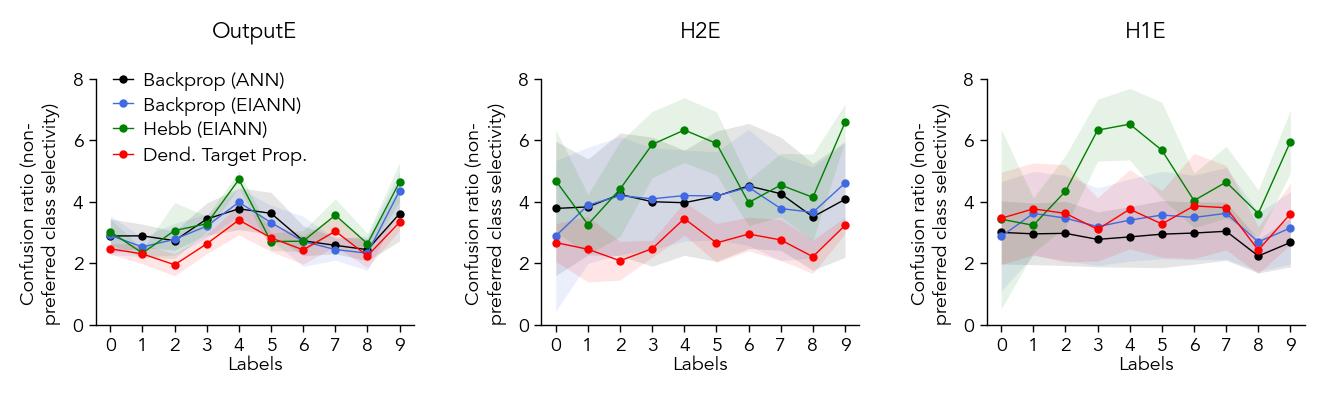

In [ ]:
fig = plt.figure(figsize=(6.5, 1.5))
axes = gs.GridSpec(nrows=1, ncols=3, figure=fig,            
                left=0.05,right=0.98,
                top=0.92, bottom=0.1,
                wspace=0.4, hspace=0.4)

ax = {'OutputE': fig.add_subplot(axes[0]),
      'H2E': fig.add_subplot(axes[1]),
      'H1E': fig.add_subplot(axes[2])}

root_dir = ut.get_project_root()

for model_key in model_list:
    model_dict = model_dict_all[model_key]
    network_name = model_dict['config'].split('.')[0]
    hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"
    with h5py.File(hdf5_path, 'r') as f:
        data_dict = f[network_name]
        # print(f"Generating plots for {model_dict['label']}")
        population = 'H2DendI'
        example_seed = model_dict['seeds'][0] # example seed to plot

        for pop in ['OutputE', 'H2E', 'H1E']:
            plot_confusion_all_seeds(data_dict, model_dict, ax=ax[pop], population=pop, type='line')
            ax[pop].set_title(pop, fontsize=8, y=1.1)
        ax['OutputE'].legend(loc='upper left', bbox_to_anchor=(0, 1.1))

fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.svg", dpi=300)
fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.png", dpi=300)